In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# **Function 1** - Searching for Contamination Sources (Radiation Detection)


For this function we must detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.

- The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

**Input** - 2D array (10,2)
**Output** - 1D array (10,)

- **Optimisation Goal** - Maximise

I want to begin this week's analysis by loading the data and exploring it.


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_1\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_1\initial_outputs.npy')

### **Random Search**

- To begin with since we have limited knowledge of the function we can conduct generic exploration using a random search of the function.


In [3]:
next_query = np.random.uniform(size = 2)
print(next_query)

[0.80838954 0.47072748]


- This is a quick and simple method but it I think it can only be used as a placeholder for the gathering more information while I research methods I want to use for each function.


### **Setting up Parameters** - More Strategic Approach


- **Decision 1** - Noise Level
  - I want to play around with the noise levels so that I can make the model tust the measurements completely.
  - In real black-box optimisations the measurements are typicaly exact unlike real-world sensors these functions return precise values.

  - By doing so the model doesn't waste queries near points which we have already tested.
    - This forces the model to look at new areas during exploration.


In [4]:
noise_assumption = 1e-10

- **Decision 2** - Kernel Choice and lengthscale
  - I will use the Matern kernel to allow for moderate non-smooth behaviour while retaining overall smoothness.


In [5]:
length_scale = 0.1

- **Decision 3** - Exploration Parameter
  - By including this in the first week we can ensure epxloration instead of exploitation.

  - Since we know nothing about this function I will want this to be quite high ($\xi$ = 0.2)


In [6]:
eta = 0.2

### **Building the actual Gaussian Process Model**


- I want to keep fixed lengthscale bounds as sklearn will optimize the `legnth_scale` automatically.


In [7]:
# Define Matern kernel with fixed lengthscale
kernel = Matern(
    length_scale = length_scale,
    length_scale_bounds = 'fixed',
    nu = 2.5,
)

# Instantiate Gaussian Process Regressor
model = GaussianProcessRegressor(
    kernel = kernel,
    alpha = noise_assumption,
    normalize_y = True,
)

# Fit the model to the initial data (pass 1D target array)
model.fit(X, Y)

GaussianProcessRegressor(kernel=Matern(length_scale=0.1, nu=2.5),
                         normalize_y=True)

### **Generating the Next Quereis**


In [9]:
x_grid = np.random.uniform(0, 1, size = (100000, 2))

post_mean, post_std = model.predict(x_grid, return_std = True)

### **Acquisition Function**


In [ ]:
xi = 0.2

y_max = np.max(Y)

with np.errstate(divide='ignore'):
    improvement = post_mean - y_max - xi
    Z = improvement / (post_std + 1e-12)
    ei = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    ei[post_std == 0.0] = 0.0

best_idx = np.argmax(ei)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 1 - Bayesian Optimisation (EI): {next_query[0]:.6f}-{next_query[1]:.6f}")

Next Submission for Function 1 - Bayesian Optimisation (EI): 0.121013-0.697967


### **Visualising the data**


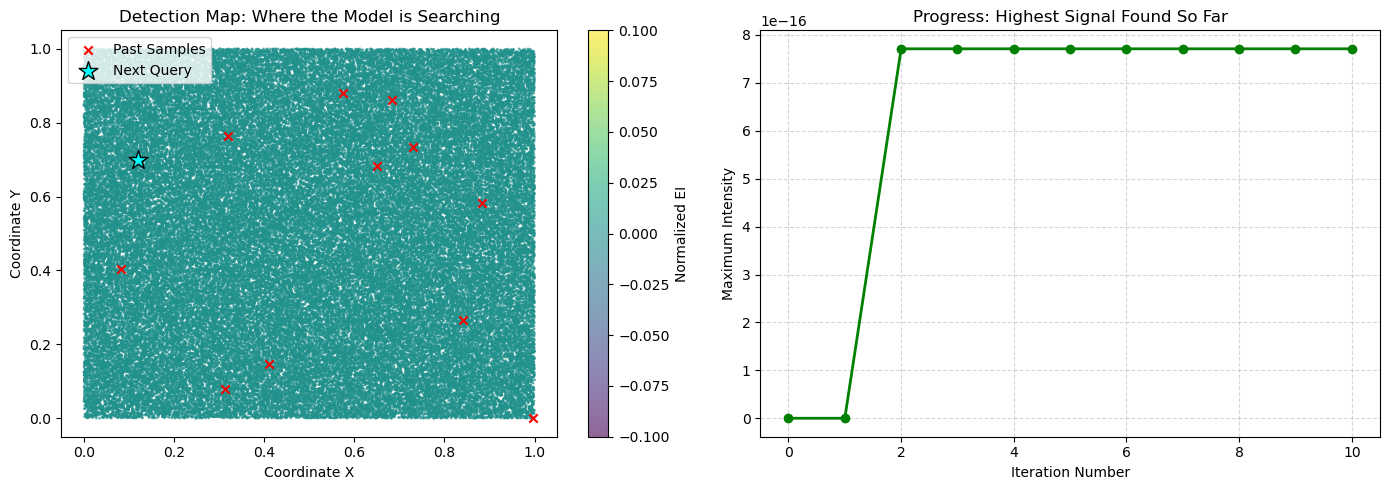

Strategic Result: Next point to query is at (0.121013-0.697967)


In [ ]:
# --- 1. Preparation for the Summary ---
# Track the best value found so far (Convergence)
running_max = np.maximum.accumulate(Y)

# --- 2. Create a Simple 2-Panel Report ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Define the acquisition function used for plotting.
# We used EI earlier and stored it in `ei`, so use that here.
# Normalize for visualization stability.
acquisition_function = ei
acq_norm = (acquisition_function - np.nanmin(acquisition_function)) / (np.nanmax(acquisition_function) - np.nanmin(acquisition_function) + 1e-12)

# PANEL 1: The Search Map (Where are we looking?)
# We use a simple scatter plot of our 'search grid' colored by the Acquisition Function
# This shows the "hot zones" the model wants to explore next.
sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='viridis', s=1, alpha=0.6)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized EI')
ax1.scatter(X[:, 0], X[:, 1], c='red', marker='x', label='Past Samples')
ax1.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=200, edgecolors='black', label='Next Query')
ax1.set_title('Detection Map: Where the Model is Searching')
ax1.set_xlabel('Coordinate X')
ax1.set_ylabel('Coordinate Y')
ax1.legend()

# PANEL 2: The Progress Plot (Are we finding anything?)
# A simple line graph showing the best detection score over time.
ax2.plot(running_max, color='green', linewidth=2, marker='o')
ax2.set_title('Progress: Highest Signal Found So Far')
ax2.set_xlabel('Iteration Number')
ax2.set_ylabel('Maximum Intensity')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Strategic Result: Next point to query is at ({next_query[0]:.6f}-{next_query[1]:.6f})")

### **Reasons for having a different input values for week 1 than what is shown here**


**Final Decision** - Due to inability of going through this process in time for week 1 submission I choose the input points which were purely based on exploration.

- **Hence the input for week 1** - 0.996651, 0.001439


I will be using this thinking process and methodology moving forward into week 2.
